# Senescent Cell Counter

Senecent cells can be differentiated by the enzimatic activity of $\beta$-gal which can be observed by the rupture (hydrolisis) of its substrate, $\beta$-galactosides into simpler sugars (monosaccharides). To asess senescence, we calcule the number of cells marked with blue aganist the total number of cells in a sample. Total cells are easily quantifiable in confocal microscopy with DAPi immunostaining.

In [2]:
path_to_dir = 'data/'
path_to_exp = 'data/'

In [3]:
import os
import cv2 as cv
import  numpy as np
from matplotlib import pyplot as plt
import re
import pandas as pd

In [4]:
def inspect_folder(path):
    ls_names = [os.path.join(path, name) for name in os.listdir(path)]
    tif_paths = {}
    for name in ls_names:
        if os.path.isdir(name):
            # merge results from subfolder
            sub_dict = inspect_folder(name)
            tif_paths.update(sub_dict)
        elif re.search(r'\.tif$', name):
            tif_paths[name.split('/')[-1]] = name
    return tif_paths


In [5]:
def count_dapi_nuclei(dapi_img, clahe=True, sharpen=True, tophat=True, low_intensity_tresh=20, min_area_nuc=40, max_area_nuc=500, kernel=None):
    """Count DAPI stained nuclei in the given image.

    Args:
        dapi_img (numpy.ndarray): Input DAPI image.
        clahe (bool, optional): Apply CLAHE. Defaults to True.
        sharpen (bool, optional): Apply sharpening. Defaults to True.
        tophat (bool, optional): Apply top-hat filtering. Defaults to True.
        save_vis (bool, optional): Save visualization image. Defaults to False.
        low_intensity_tresh (int, optional): Low intensity threshold. Defaults to 20.
        min_px_size (int, optional): Minimum pixel size for nuclei. Defaults to 50. 
        max_px_size (int, optional): Maximum pixel size for nuclei. Defaults to 300.
        kernel (numpy.ndarray, optional): Kernel for sharpening filter. Defaults to np.array([[0, -1, 0],[-1, 5, -1],[0, -1, 0]]).
    Returns:
        tuple: (total_nuclei_count, single_nuclei_contours, agglomerate_contours, visualization_image)
    """
    if kernel is None:
        kernel = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])
    # Contrast enhancement for DAPI using CLAHE on L channel of LAB color space
    if clahe:
        
        lab = cv.cvtColor(dapi_img, cv.COLOR_BGR2LAB)
        l, a, b = cv.split(lab)
        clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))   # tweak clipLimit/tileGridSize if needed
        l_clahe = clahe.apply(l)
        lab_clahe = cv.merge((l_clahe, a, b))
        clahe_dapi = cv.cvtColor(lab_clahe, cv.COLOR_LAB2BGR)
    else:
        clahe_dapi = dapi_img.copy()

    # Sharpening filter
    if sharpen:
        sharpened_dapi = cv.filter2D(clahe_dapi, -1, kernel)
    else:
        sharpened_dapi = clahe_dapi.copy()

    #Tophat to reduce overlap
    if tophat:
        tophat_dapi = cv.morphologyEx(sharpened_dapi, cv.MORPH_OPEN, kernel = np.ones((9,9),np.uint8))
    else:
        tophat_dapi = sharpened_dapi.copy()
    
    # Compute DAPI contours (no filtering), then classify single nuclei vs agglomerates
    gray = cv.cvtColor(tophat_dapi, cv.COLOR_BGR2GRAY)
    _, dapi_mask_full = cv.threshold(gray, low_intensity_tresh, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    dapi_mask_full = cv.morphologyEx(dapi_mask_full, cv.MORPH_OPEN, cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3)))
    dapi_contours_all, _ = cv.findContours(dapi_mask_full, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # classify contours by area
    single_nuclei = [c for c in dapi_contours_all if min_area_nuc < cv.contourArea(c) <= max_area_nuc]
    agglomerates = [c for c in dapi_contours_all if cv.contourArea(c) > max_area_nuc]

    # prepare masks for overlap tests
    agglom_mask = np.zeros_like(dapi_mask_full)
    cv.drawContours(agglom_mask, agglomerates, -1, 255, thickness=cv.FILLED)

    # compute centroids for single nuclei
    centroids = []
    for c in single_nuclei:
        M = cv.moments(c)
        if M['m00'] != 0:
            cx = int(M['m10']/M['m00']); cy = int(M['m01']/M['m00'])
            centroids.append((cx, cy))
        else:
            centroids.append(None)
    # Visualization
    out_vis = dapi_img.copy()
    cv.drawContours(out_vis, single_nuclei, -1, (0,255,0), 2)  # Green for single nuclei
    cv.drawContours(out_vis, agglomerates, -1, (100,100,100), 2)    # Black for agglomerates
    for c in centroids:
        if c is not None:
            cv.drawMarker(out_vis, c, (0,0,255), markerType=cv.MARKER_STAR, markerSize=12, thickness=2)  # Red star for centroids
    return len(single_nuclei), single_nuclei, agglomerates, agglom_mask, centroids, out_vis
    
        


In [6]:
def find_blue_zones(bgal_img, sharpen=True, kernel=None, min_area=100):
    if kernel is None:
        kernel = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])
    if sharpen:
        sharpened_bgal = cv.filter2D(bgal_img,-1,kernel=kernel)
    else: sharpened_bgal = bgal_img.copy()

    # extract blue-marked shapes from sharpened_bgal and plot contours
    b = sharpened_bgal[:, :, 0].astype(int)
    g = sharpened_bgal[:, :, 1].astype(int)
    r = sharpened_bgal[:, :, 2].astype(int)

    # blue dominance measure (blue stronger than red/green)
    blue_dom = b - ((g + r) // 2)
    blue_dom = np.clip(blue_dom, 0, 255).astype('uint8')

    # binary mask (adjust thresh if needed)
    _, blue_mask = cv.threshold(blue_dom, 8, 255, cv.THRESH_BINARY)

    # clean mask
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (10, 10))
    blue_mask = cv.morphologyEx(blue_mask, cv.MORPH_OPEN, kernel, iterations=1)
    blue_mask = cv.morphologyEx(blue_mask, cv.MORPH_CLOSE, kernel, iterations=1)

    # find and filter contours by area
    blue_contours, _ = cv.findContours(blue_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    blue_contours = [c for c in blue_contours if cv.contourArea(c) >= min_area]

    # draw contours on a copy
    out_img = sharpened_bgal.copy()
    cv.drawContours(out_img, blue_contours, -1, (255, 255, 0), 2)
    print(f'Found {len(blue_contours)} blue-marked shapes (area >= {min_area})')
    return blue_contours, blue_mask, out_img    

    


In [7]:
def count_bgal_nuclei(single_nuclei, blue_contours, blue_mask, agglomerates ,agglom_mask, centroids, bgal_img):
    # Count single nuclei and those within blue regions
    total_n = len(single_nuclei)  # Total single nuclei count
    n_bgal = 0  # Count of nuclei within blue regions
    counted_nuclei_idx = set()  # To track counted nuclei

    # Visualization: draw blue contours, agglomerates (black), and counted nuclei (red stars)
    out_vis = bgal_img.copy()

    for i, bcont in enumerate(blue_contours):
        # Create mask for the blue contour
        blue_mask_i = np.zeros_like(blue_mask)
        cv.drawContours(blue_mask_i, [bcont], -1, 255, thickness=cv.FILLED)
        
        # Check overlap with agglomerates
        overlap_area = np.sum(cv.bitwise_and(blue_mask_i, agglom_mask))
        if overlap_area > cv.contourArea(bcont) *50:
            continue  # Skip if overlap is greater than half of blue region area
        
        # Check which single-nuclei centroids fall inside the blue contour
        inside_nuclei = []
        for j, c in enumerate(single_nuclei):
            if centroids[j] is None:
                continue
            inside = cv.pointPolygonTest(bcont, centroids[j], measureDist=True)
            if inside >= -1:  # Inside or on edge
                counted_nuclei_idx.add(j)
                inside_nuclei.append(j)
        
        # Count blue region if no nuclei centroids are inside
        if not inside_nuclei:
            n_bgal += 1  # Count this blue region as 1
            # Mark centroid of blue region
            M = cv.moments(bcont)
            if M['m00'] != 0:
                cx = int(M['m10'] / M['m00'])
                cy = int(M['m01'] / M['m00'])
                cv.drawMarker(out_vis, (cx, cy), (255, 0, 255), markerType=cv.MARKER_STAR, markerSize=12, thickness=2)
        else:
            n_bgal += len(inside_nuclei)  # Count the number of centroids found inside

    # Final counts
    print(f"Total single nuclei: {total_n}")
    print(f"Nuclei inside blue Bgal regions: {n_bgal}")
    print(f'Percentage of senecent cells: {n_bgal/total_n*100:.2f}%')


    # blue marks for counted nuclei
    cv.drawContours(out_vis, single_nuclei, -1, (255,0,0), 2)
    # Draw blue contours
    cv.drawContours(out_vis, blue_contours, -1, (220, 220, 0), 2)
    # Draw agglomerates
    cv.drawContours(out_vis, agglomerates, -1, (50, 50, 50), 2)
    # Draw counted nuclei centroids
    for idx in counted_nuclei_idx:
        cx, cy = centroids[idx]
        cv.drawMarker(out_vis, (cx, cy), (0, 0, 255), markerType=cv.MARKER_STAR, markerSize=12, thickness=2)
    return n_bgal, total_n, out_vis
    

In [8]:
def process_chunck(folder_path, min_blue_area=250, min_area_nuc=40, max_area_nuc=700):
    # Get image paths
    img_paths = inspect_folder(folder_path)
    # Parse filenames
    image_groups = {}
    for filename, filepath in img_paths.items():
        # Parse filename: e.g., "2.5_DAPI_6DIV.tif" -> well=2.5, imgtype=DAPI, div=6DIV
        match = re.match(r'(\d+(?:\.\d+)?)\_(Bgal|DAPI)\_(\d+DIV)\.tif', filename)
        if match:
            exp_id, imgtype, div = match.groups()
            # Extract CPNC from path
            path_parts = filepath.split('/')
            folder_name = path_parts[-3]  # e.g., "Bgal 6DIV ctrl CPNC 19"
            cpnc_match = re.search(r'CPNC (\d+)', folder_name)
            cpnc = cpnc_match.group(1) if cpnc_match else 'unknown'
            div_num = int(div.replace('DIV', ''))
            
            pozo = path_parts[-2]  # e.g., "Pozo 2"
            
            key = (cpnc, div_num, exp_id, pozo)
            if key not in image_groups:
                image_groups[key] = {}
            image_groups[key][imgtype] = filepath

    # Process each image pair
    results = []
    for (cpnc, div_num, exp_id, pozo), image_dict in image_groups.items():
        if 'DAPI' in image_dict and 'Bgal' in image_dict:
            # Load images
            dapi_img = cv.imread(image_dict['DAPI'])
            bgal_img = cv.imread(image_dict['Bgal'])
            
            # Count DAPI nuclei
            n_dapi, single_nuclei, agglomerates, agglom_mask, centroids, _ = count_dapi_nuclei(
                dapi_img, kernel=np.array([[0, -1, 0],[-1, 5.4, -1], [0, -1, 0]]),
                min_area_nuc=min_area_nuc, max_area_nuc=max_area_nuc
            )
            
            # Find blue zones
            blue_contours, blue_mask, _ = find_blue_zones(bgal_img, sharpen=True, min_area=min_blue_area, kernel=np.array([[0, -1, 0],[-1, 5.4, -1], [0, -1, 0]]))
            
            # Count bgal_cells
            n_bgal, n_dapi, out_vis = count_bgal_nuclei(single_nuclei, blue_contours, blue_mask, agglomerates ,agglom_mask, centroids, bgal_img)
            
            results.append({
                'CPNC': cpnc,
                'DIV': div_num,
                'Sample': exp_id,
                'Well': pozo,
                'n_bgal': n_bgal,
                'dapi_n': n_dapi
            })
            print(f"Processed: CPNC {cpnc}, DIV {div_num}, Sample {exp_id}, Well {pozo} - DAPI: {n_dapi}, Bgal: {n_bgal}")
            
            plt.figure(figsize=(8, 8))
            plt.imshow(cv.cvtColor(out_vis, cv.COLOR_BGR2RGB))
            plt.title(f'Counted nuclei (red stars), Expected nuclei (magenta) , Agglom. (black), bGal regions (cyan), DAPI nuclei (blue), n={n_dapi}, bgal={n_bgal}, sene={n_bgal/n_dapi*100:.2f}%', fontdict={'fontsize': 6})
            plt.axis('off')
            plt.savefig(os.path.join('./results/visualizations', f'{exp_id}_CPNC{cpnc}_DIV{div_num}_counts.png'))
    return results
        

In [9]:
!mkdir -p ./results/visualizations/

Found 50 blue-marked shapes (area >= 200)
Total single nuclei: 490
Nuclei inside blue Bgal regions: 50
Percentage of senecent cells: 10.20%
Processed: CPNC unknown, DIV 26, Sample 2.5, Well Bgal 27DIV CPNC 17 - DAPI: 490, Bgal: 50


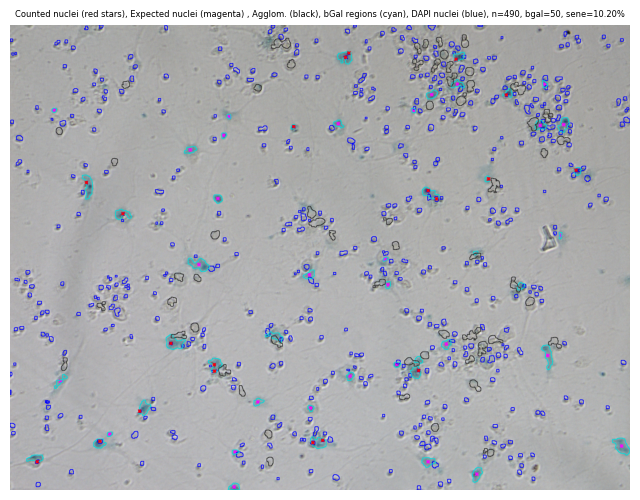

In [12]:
df = process_chunck('data/Bgal 27DIV CPNC 17', min_blue_area=200, min_area_nuc=40, max_area_nuc=600)

In [1]:
#df1 = process_chunck('/media/raqcoss/USB KGST/Lorelei/Bgal 26DIV CPNC 15', min_blue_area=200, min_area_nuc=40, max_area_nuc=600)

In [13]:
#df2 = process_chunck('/media/raqcoss/USB KGST/Lorelei/Bgal 27DIV CPNC 17', min_blue_area=500, min_area_nuc=40, max_area_nuc=700)

In [3]:
#df3 = process_chunck('/media/raqcoss/USB KGST/Lorelei/Bgal 6DIV ctrl CPNC 19', min_blue_area=600, min_area_nuc=80, max_area_nuc=1400) 

df1 = pd.DataFrame(df1)
df2 = pd.DataFrame(df2)
df3 = pd.DataFrame(df3)
df = pd.concat([df1, df2, df3],axis=0)

In [16]:
df = pd.DataFrame(df)

In [17]:
df['senescent_perc'] = df['n_bgal']/df['dapi_n']*100

In [18]:
df.to_csv('./results/senescence_counts.csv')

In [19]:
df

,CPNC,DIV,Sample,Well,n_bgal,dapi_n,senescent_perc
0,unknown,26,2.5,Bgal 27DIV CPNC 17,50,490,10.204082


In [20]:
# in detail
inspect_folder(path_to_exp)

{'2.5_Bgal_26DIV.tif': 'data/Bgal 27DIV CPNC 17/2.5_Bgal_26DIV.tif',
 '2.5_DAPI_26DIV.tif': 'data/Bgal 27DIV CPNC 17/2.5_DAPI_26DIV.tif'}

In [21]:
bgal_img = cv.imread('data/Bgal 27DIV CPNC 17/2.5_Bgal_26DIV.tif')
dapi_img = cv.imread('data/Bgal 27DIV CPNC 17/2.5_DAPI_26DIV.tif')

In [22]:
n_nuclei, single_nuclei, agglomerates, agglom_mask, centroids, out_vis = count_dapi_nuclei(dapi_img)

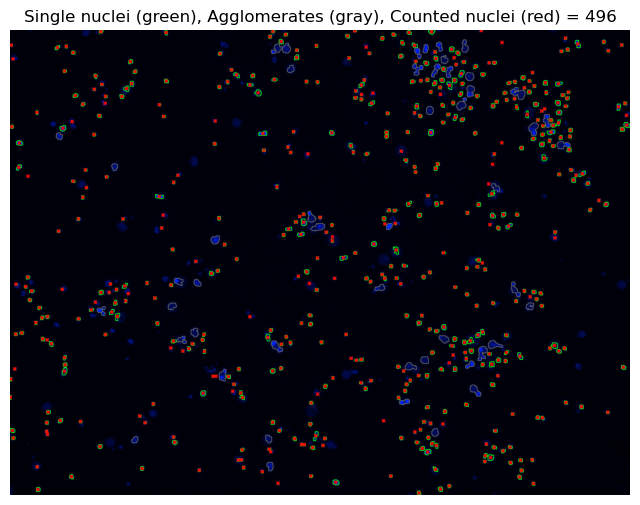

In [23]:
# Compute DAPI contours (no filtering), then classify single nuclei vs agglomerates

plt.figure(figsize=(8,8))
plt.imshow(cv.cvtColor(out_vis, cv.COLOR_BGR2RGB))
plt.title(f'Single nuclei (green), Agglomerates (gray), Counted nuclei (red) = {n_nuclei}')
plt.axis('off')
plt.show()

In [24]:
blue_contours, blue_mask, out_vis = find_blue_zones(bgal_img, sharpen=True, min_area=400, kernel=np.array([[0, -1, 0],[-1, 5.4, -1], [0, -1, 0]]))


Found 41 blue-marked shapes (area >= 400)


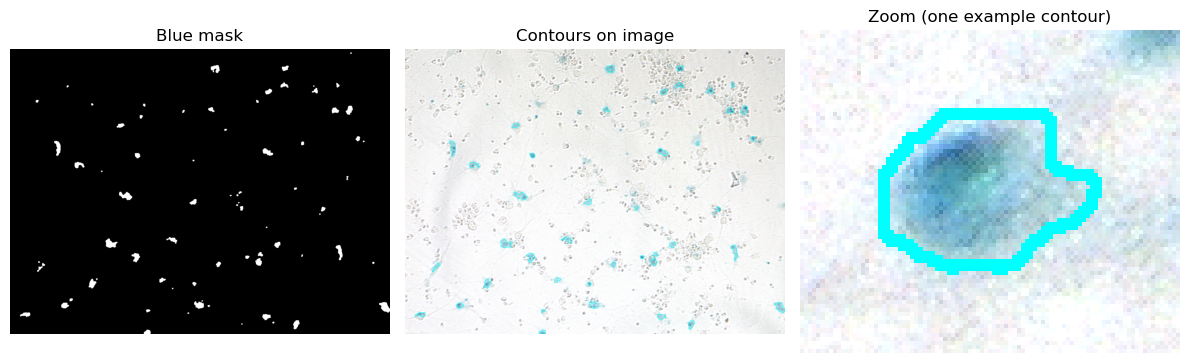

In [27]:

# plot mask, full image with contours and zoom on first contour
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Blue mask')
plt.axis('off')
plt.imshow(blue_mask, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Contours on image')
plt.axis('off')
plt.imshow(cv.cvtColor(out_vis, cv.COLOR_BGR2RGB))

plt.subplot(1, 3, 3)
plt.title('Zoom (one example contour)')
plt.axis('off')
if blue_contours:
    x, y, w, h = cv.boundingRect(blue_contours[5])
    crop = out_vis[max(y-20,0):y+h+20, max(x-20,0):x+w+20]
    plt.imshow(cv.cvtColor(crop, cv.COLOR_BGR2RGB))
else:
    plt.text(0.5, 0.5, 'No contours found', ha='center', va='center')

plt.tight_layout()
plt.show()


In [28]:
df['Well']= [a.split(' ')[1] for a in df['Well']]

In [29]:
df.columns

Index(['CPNC', 'DIV', 'Sample', 'Well', 'n_bgal', 'dapi_n', 'senescent_perc'], dtype='object')

In [162]:
## Validation
val_df = pd.read_csv('/media/raqcoss/USB KGST/Lorelei/human_validation.csv', sep='\t')
val_df['senescent_perc'] = val_df['n_bgal']/ val_df['dapi_n']*100


In [163]:
val_df.columns

Index(['CPNC', 'DIV', 'Sample', 'Well', 'n_bgal', 'dapi_n', 'senescent_perc'], dtype='object')

Successfully matched 23 samples
                      n_bgal_auto  dapi_n_auto  senescent_perc_auto  \
CPNC DIV Sample Well                                                  
15   26  1.2    1              32          334             9.580838   
         1.3    1              14          231             6.060606   
         1.5    1              18          205             8.780488   
         1.0    1              27          341             7.917889   
         1.4    1              18          196             9.183673   

                      n_bgal_human  dapi_n_human  senescent_perc_human  
CPNC DIV Sample Well                                                    
15   26  1.2    1               13           327              3.975535  
         1.3    1               15           207              7.246377  
         1.5    1               18           193              9.326425  
         1.0    1               37           336             11.011905  
         1.4    1               

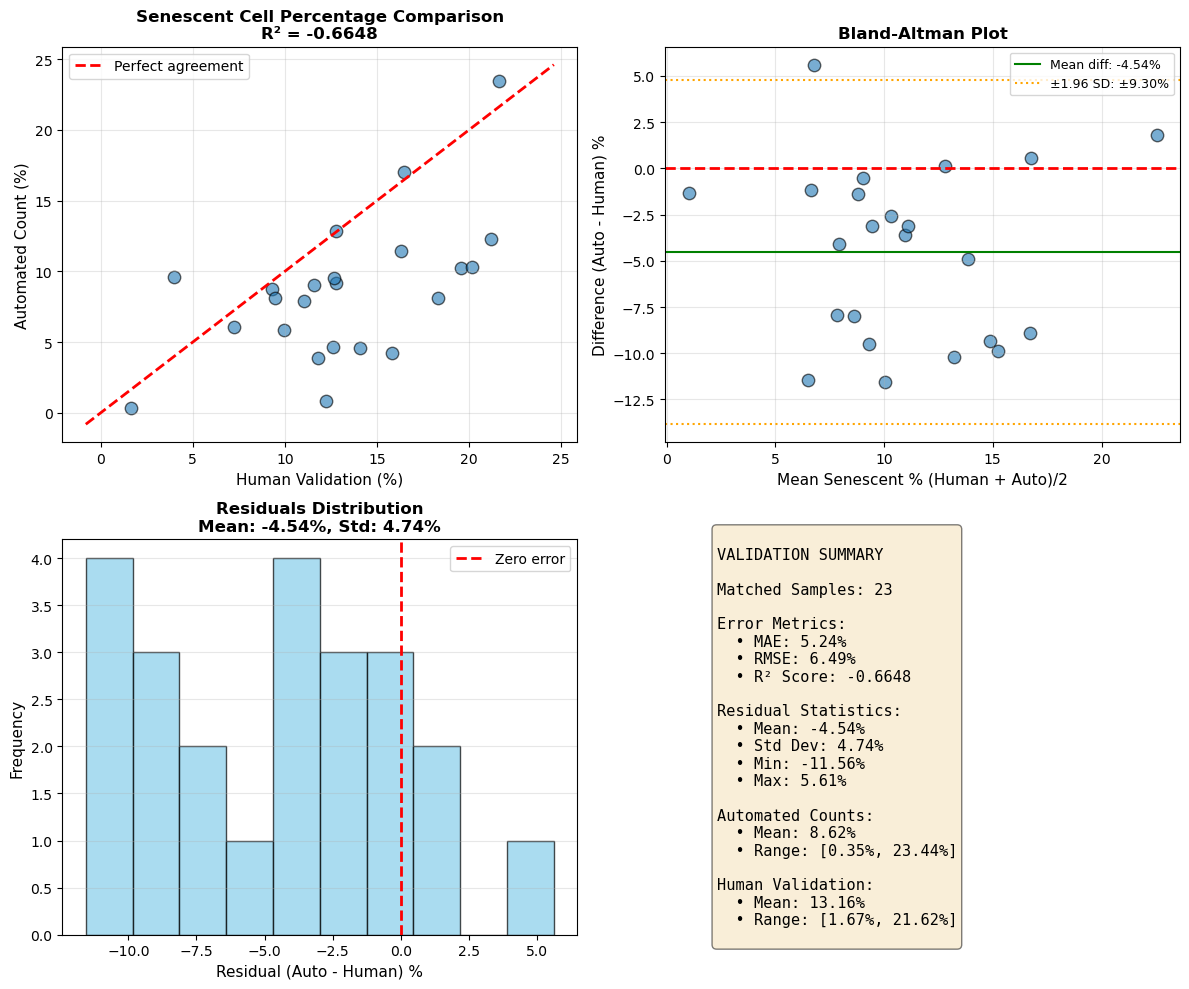


Validation plot saved to: ./results/cross_validation_analysis.png


In [164]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load and prepare data
val_df = pd.read_csv('/media/raqcoss/USB KGST/Lorelei/human_validation.csv', sep='\t')
val_df['senescent_perc'] = val_df['n_bgal'] / val_df['dapi_n'] * 100

# Ensure consistent data types and formats
merge_cols = ['CPNC', 'DIV', 'Sample', 'Well']

# Convert to same dtypes
for col in merge_cols:
    df[col] = df[col].astype(str).str.strip()
    val_df[col] = val_df[col].astype(str).str.strip()

# Convert numeric columns back to int/float where appropriate
df['CPNC'] = df['CPNC'].astype(int)
df['DIV'] = df['DIV'].astype(int)
df['Sample'] = df['Sample'].astype(float)

val_df['CPNC'] = val_df['CPNC'].astype(int)
val_df['DIV'] = val_df['DIV'].astype(int)
val_df['Sample'] = val_df['Sample'].astype(float)

# Set index for both
df_indexed = df.set_index(merge_cols)
val_df_indexed = val_df.set_index(merge_cols)

# Inner join to get common samples
comparison_df = df_indexed.join(val_df_indexed, lsuffix='_auto', rsuffix='_human', how='inner')

print(f"Successfully matched {len(comparison_df)} samples")
print(comparison_df.head())

# Calculate error metrics
mae = mean_absolute_error(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto'])
rmse = np.sqrt(mean_squared_error(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto']))
r2 = r2_score(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto'])

print(f"\nCross-Validation Results:")
print(f"  MAE: {mae:.2f}%")
print(f"  RMSE: {rmse:.2f}%")
print(f"  R² Score: {r2:.4f}")
print(f"  Samples compared: {len(comparison_df)}")

# Plot 1: Scatter plot with identity line
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.scatter(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto'], s=80, alpha=0.6, edgecolors='black')
lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect agreement')
ax.set_xlabel('Human Validation (%)', fontsize=11)
ax.set_ylabel('Automated Count (%)', fontsize=11)
ax.set_title(f'Senescent Cell Percentage Comparison\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Bland-Altman plot
ax = axes[0, 1]
mean_vals = (comparison_df['senescent_perc_human'] + comparison_df['senescent_perc_auto']) / 2
diff_vals = comparison_df['senescent_perc_auto'] - comparison_df['senescent_perc_human']
ax.scatter(mean_vals, diff_vals, s=80, alpha=0.6, edgecolors='black')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
mean_diff = diff_vals.mean()
std_diff = diff_vals.std()
ax.axhline(y=mean_diff, color='g', linestyle='-', lw=1.5, label=f'Mean diff: {mean_diff:.2f}%')
ax.axhline(y=mean_diff + 1.96*std_diff, color='orange', linestyle=':', lw=1.5, label=f'±1.96 SD: ±{1.96*std_diff:.2f}%')
ax.axhline(y=mean_diff - 1.96*std_diff, color='orange', linestyle=':', lw=1.5)
ax.set_xlabel('Mean Senescent % (Human + Auto)/2', fontsize=11)
ax.set_ylabel('Difference (Auto - Human) %', fontsize=11)
ax.set_title('Bland-Altman Plot', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Residuals distribution
ax = axes[1, 0]
residuals = comparison_df['senescent_perc_auto'] - comparison_df['senescent_perc_human']
ax.hist(residuals, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero error')
ax.set_xlabel('Residual (Auto - Human) %', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Residuals Distribution\nMean: {residuals.mean():.2f}%, Std: {residuals.std():.2f}%', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Error metrics summary
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
VALIDATION SUMMARY

Matched Samples: {len(comparison_df)}

Error Metrics:
  • MAE: {mae:.2f}%
  • RMSE: {rmse:.2f}%
  • R² Score: {r2:.4f}

Residual Statistics:
  • Mean: {residuals.mean():.2f}%
  • Std Dev: {residuals.std():.2f}%
  • Min: {residuals.min():.2f}%
  • Max: {residuals.max():.2f}%

Automated Counts:
  • Mean: {comparison_df['senescent_perc_auto'].mean():.2f}%
  • Range: [{comparison_df['senescent_perc_auto'].min():.2f}%, {comparison_df['senescent_perc_auto'].max():.2f}%]

Human Validation:
  • Mean: {comparison_df['senescent_perc_human'].mean():.2f}%
  • Range: [{comparison_df['senescent_perc_human'].min():.2f}%, {comparison_df['senescent_perc_human'].max():.2f}%]
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('./results/cross_validation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nValidation plot saved to: ./results/cross_validation_analysis.png")

In [165]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Merge on index columns
merge_cols = ['CPNC', 'DIV', 'Sample', 'Well']
df_indexed = df.set_index(merge_cols)
val_df_indexed = val_df.set_index(merge_cols)

# Inner join to get common samples
comparison_df = df_indexed.join(val_df_indexed, lsuffix='_auto', rsuffix='_human', how='outer')
comparison_df

n_bgal_auto  dapi_n_auto  senescent_perc_auto  \
CPNC DIV Sample Well                                                  
15   26  1.0    1              27          341             7.917889   
         1.2    1              32          334             9.580838   
         1.3    1              14          231             6.060606   
         1.4    1              18          196             9.183673   
         1.5    1              18          205             8.780488   
         2.0    2              36          399             9.022556   
         2.2    2              50          389            12.853470   
         2.3    2              23          284             8.098592   
         2.4    2              19          489             3.885481   
         2.5    2              50          490            10.204082   
         3.0    3              17          149            11.409396   
         3.2    3              31          182            17.032967   
         3.3    3              64          273            23.443223   
17   27  1.0    1              30          314             9.554140   
         1.2    1              14          306             4.575163   
         1.3    1               1          286             0.349650   
         1.4    1              15          256             5.859375   
         1.5    1              28          228            12.280702   
         2.0    2               2          249             0.803213   
         2.2    2              22          214            10.280374   
         2.3    2              11          258             4.263566   
         2.4    2              20          246             8.130081   
         2.5    2              11          238             4.621849   
19   6   1.0    1               0          233             0.000000   
         1.2    1               0          170             0.000000   
         1.3    1               0          305             0.000000   
         1.4    1               0          199             0.000000   
         1.5    1               0          170             0.000000   
         2.0    2               0          117             0.000000   
         2.2    2               0          171             0.000000   
         2.3    2               0          151             0.000000   
         2.4    2               0          233             0.000000   
         2.5    2               0          216             0.000000   
         3.0    3              19          178            10.674157   
         3.2    3              12          162             7.407407   
         3.3    3               5          152             3.289474   
         3.4    3               0          185             0.000000   
         3.5    3               2          131             1.526718   

                      n_bgal_human  dapi_n_human  senescent_perc_human  
CPNC DIV Sample Well                                                    
15   26  1.0    1             37.0         336.0             11.011905  
         1.2    1             13.0         327.0              3.975535  
         1.3    1             15.0         207.0              7.246377  
         1.4    1             24.0         188.0             12.765957  
         1.5    1             18.0         193.0              9.326425  
         2.0    2             19.0         164.0             11.585366  
         2.2    2             32.0         251.0             12.749004  
         2.3    2             23.0         243.0              9.465021  
         2.4    2             19.0         161.0             11.801242  
         2.5    2             36.0         184.0             19.565217  
         3.0    3             24.0         147.0             16.326531  
         3.2    3             27.0         164.0             16.463415  
         3.3    3             32.0         148.0             21.621622  
17   27  1.0    1             34.0         268.0             12.686567  
         1.2 

Successfully matched 23 samples
                      n_bgal_auto  dapi_n_auto  senescent_perc_auto  \
CPNC DIV Sample Well                                                  
15   26  1.2    1              32          334             9.580838   
         1.3    1              14          231             6.060606   
         1.5    1              18          205             8.780488   
         1.0    1              27          341             7.917889   
         1.4    1              18          196             9.183673   

                      n_bgal_human  dapi_n_human  senescent_perc_human  
CPNC DIV Sample Well                                                    
15   26  1.2    1               13           327              3.975535  
         1.3    1               15           207              7.246377  
         1.5    1               18           193              9.326425  
         1.0    1               37           336             11.011905  
         1.4    1               

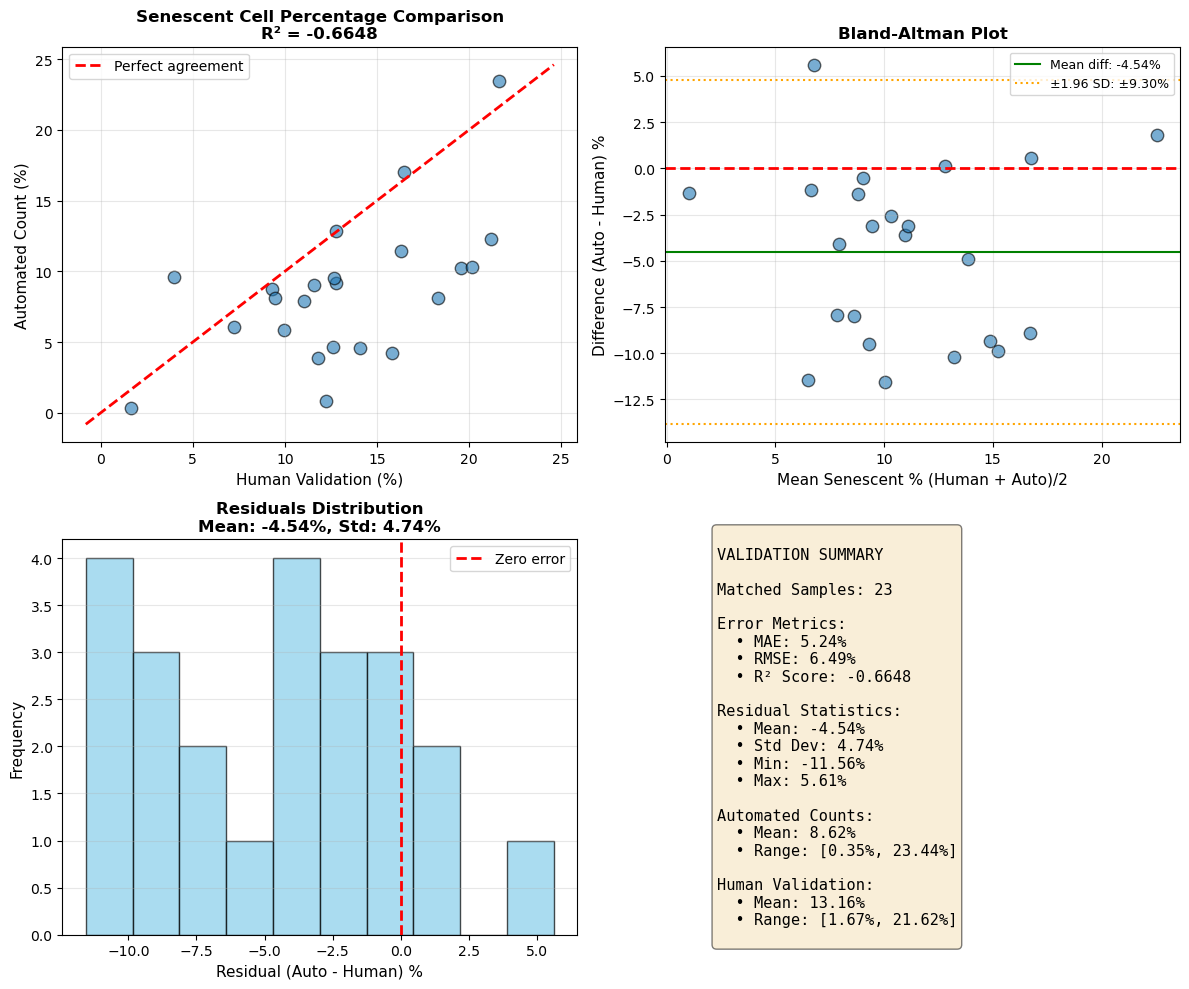


Validation plot saved to: ./results/cross_validation_analysis.png


In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load and prepare data
val_df = pd.read_csv('/media/raqcoss/USB KGST/Lorelei/human_validation.csv', sep='\t')
val_df['senescent_perc'] = val_df['n_bgal'] / val_df['dapi_n'] * 100

# Ensure consistent data types and formats
merge_cols = ['CPNC', 'DIV', 'Sample', 'Well']

# Convert to same dtypes
for col in merge_cols:
    df[col] = df[col].astype(str).str.strip()
    val_df[col] = val_df[col].astype(str).str.strip()

# Convert numeric columns back to int/float where appropriate
df['CPNC'] = df['CPNC'].astype(int)
df['DIV'] = df['DIV'].astype(int)
df['Sample'] = df['Sample'].astype(float)

val_df['CPNC'] = val_df['CPNC'].astype(int)
val_df['DIV'] = val_df['DIV'].astype(int)
val_df['Sample'] = val_df['Sample'].astype(float)

# Set index for both
df_indexed = df.set_index(merge_cols)
val_df_indexed = val_df.set_index(merge_cols)

# Inner join to get common samples
comparison_df = df_indexed.join(val_df_indexed, lsuffix='_auto', rsuffix='_human', how='inner')

print(f"Successfully matched {len(comparison_df)} samples")
print(comparison_df.head())

# Calculate error metrics
mae = mean_absolute_error(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto'])
rmse = np.sqrt(mean_squared_error(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto']))
r2 = r2_score(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto'])

print(f"\nCross-Validation Results:")
print(f"  MAE: {mae:.2f}%")
print(f"  RMSE: {rmse:.2f}%")
print(f"  R² Score: {r2:.4f}")
print(f"  Samples compared: {len(comparison_df)}")

# Plot 1: Scatter plot with identity line
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.scatter(comparison_df['senescent_perc_human'], comparison_df['senescent_perc_auto'], s=80, alpha=0.6, edgecolors='black')
lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect agreement')
ax.set_xlabel('Human Validation (%)', fontsize=11)
ax.set_ylabel('Automated Count (%)', fontsize=11)
ax.set_title(f'Senescent Cell Percentage Comparison\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Bland-Altman plot
ax = axes[0, 1]
mean_vals = (comparison_df['senescent_perc_human'] + comparison_df['senescent_perc_auto']) / 2
diff_vals = comparison_df['senescent_perc_auto'] - comparison_df['senescent_perc_human']
ax.scatter(mean_vals, diff_vals, s=80, alpha=0.6, edgecolors='black')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
mean_diff = diff_vals.mean()
std_diff = diff_vals.std()
ax.axhline(y=mean_diff, color='g', linestyle='-', lw=1.5, label=f'Mean diff: {mean_diff:.2f}%')
ax.axhline(y=mean_diff + 1.96*std_diff, color='orange', linestyle=':', lw=1.5, label=f'±1.96 SD: ±{1.96*std_diff:.2f}%')
ax.axhline(y=mean_diff - 1.96*std_diff, color='orange', linestyle=':', lw=1.5)
ax.set_xlabel('Mean Senescent % (Human + Auto)/2', fontsize=11)
ax.set_ylabel('Difference (Auto - Human) %', fontsize=11)
ax.set_title('Bland-Altman Plot', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Residuals distribution
ax = axes[1, 0]
residuals = comparison_df['senescent_perc_auto'] - comparison_df['senescent_perc_human']
ax.hist(residuals, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero error')
ax.set_xlabel('Residual (Auto - Human) %', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Residuals Distribution\nMean: {residuals.mean():.2f}%, Std: {residuals.std():.2f}%', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Error metrics summary
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
VALIDATION SUMMARY

Matched Samples: {len(comparison_df)}

Error Metrics:
  • MAE: {mae:.2f}%
  • RMSE: {rmse:.2f}%
  • R² Score: {r2:.4f}

Residual Statistics:
  • Mean: {residuals.mean():.2f}%
  • Std Dev: {residuals.std():.2f}%
  • Min: {residuals.min():.2f}%
  • Max: {residuals.max():.2f}%

Automated Counts:
  • Mean: {comparison_df['senescent_perc_auto'].mean():.2f}%
  • Range: [{comparison_df['senescent_perc_auto'].min():.2f}%, {comparison_df['senescent_perc_auto'].max():.2f}%]

Human Validation:
  • Mean: {comparison_df['senescent_perc_human'].mean():.2f}%
  • Range: [{comparison_df['senescent_perc_human'].min():.2f}%, {comparison_df['senescent_perc_human'].max():.2f}%]
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('./results/cross_validation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nValidation plot saved to: ./results/cross_validation_analysis.png")